## Semana 4 Dia 4 - preparando o grande projeto!

# O Sidekick

É hora de apresentar:

1. Saídas Estruturadas
2. Um fluxo multiagente

In [1]:
from typing import Annotated, TypedDict, List, Dict, Any, Optional
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage
from langchain_openai import ChatOpenAI
from langchain_community.agent_toolkits import PlayWrightBrowserToolkit
from langchain_community.tools.playwright.utils import create_async_playwright_browser
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.prebuilt import ToolNode
from langgraph.graph.message import add_messages
from pydantic import BaseModel, Field
from IPython.display import Image, display
import gradio as gr
import uuid
from dotenv import load_dotenv

In [2]:
load_dotenv(override=True)

True

### Para saídas estruturadas, definimos um objeto Pydantic para o esquema


In [3]:
# Primeiro definimos uma saída estruturada

class EvaluatorOutput(BaseModel):
    feedback: str = Field(description="Feedback sobre a resposta do assistente")
    success_criteria_met: bool = Field(description="Se os critérios de sucesso foram atendidos")
    user_input_needed: bool = Field(description="Verdadeiro se for necessário mais input do usuário, esclarecimentos ou se o assistente estiver travado")


### E para o State, usaremos TypedDict novamente

Mas agora temos algumas informações reais para manter!

As mensagens usam o reducer. Os demais são simplesmente valores que sobrescrevemos a cada mudança de estado.


In [4]:
# O estado

class State(TypedDict):
    messages: Annotated[List[Any], add_messages]
    success_criteria: str
    feedback_on_work: Optional[str]
    success_criteria_met: bool
    user_input_needed: bool


In [5]:
# Obtenha nossas ferramentas assíncronas do Playwright
# Se você receber um NotImplementedError aqui ou depois, veja o aviso no topo do notebook 3_lab3


import nest_asyncio
nest_asyncio.apply()
async_browser =  create_async_playwright_browser(headless=False)  # headful mode
toolkit = PlayWrightBrowserToolkit.from_browser(async_browser=async_browser)
tools = toolkit.get_tools()


In [6]:
# Inicializamos os LLMs

worker_llm = ChatOpenAI(model="gpt-5-mini")
worker_llm_with_tools = worker_llm.bind_tools(tools)

evaluator_llm = ChatOpenAI(model="gpt-5-mini")
evaluator_llm_with_output = evaluator_llm.with_structured_output(EvaluatorOutput)


In [7]:
# O nó worker

def worker(state: State) -> Dict[str, Any]:
    system_message = f"""Você é um assistente prestativo que pode usar ferramentas para concluir tarefas.
Você continua trabalhando em uma tarefa até ter uma pergunta ou solicitação de esclarecimento para o usuário, ou até que os critérios de sucesso sejam atendidos.
Estes são os critérios de sucesso:
{state['success_criteria']}
Você deve responder ou com uma pergunta para o usuário sobre esta tarefa, ou com sua resposta final.
Se tiver uma pergunta para o usuário, responda afirmando claramente a sua pergunta. Um exemplo seria:

Question: por favor, esclareça se você quer um resumo ou uma resposta detalhada

Se você terminou, responda com a resposta final e não faça uma pergunta; simplesmente responda com a resposta.
"""
    
    if state.get("feedback_on_work"):
        system_message += f"""
Anteriormente você achou que havia concluído a tarefa, mas sua resposta foi rejeitada porque os critérios de sucesso não foram atendidos.
Aqui está o feedback sobre o motivo dessa rejeição:
{state['feedback_on_work']}
Com esse feedback, continue a tarefa garantindo que cumpra os critérios de sucesso ou tenha uma pergunta para o usuário."""
    
    # Inclua a mensagem do sistema

    found_system_message = False
    messages = state["messages"]
    for message in messages:
        if isinstance(message, SystemMessage):
            message.content = system_message
            found_system_message = True
    
    if not found_system_message:
        messages = [SystemMessage(content=system_message)] + messages
    
    # Invocar o LLM com as ferramentas
    response = worker_llm_with_tools.invoke(messages)
    
    # Retornar o estado atualizado
    return {
        "messages": [response],
    }

In [8]:
def worker_router(state: State) -> str:
    last_message = state["messages"][-1]
    
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        return "tools"
    else:
        return "evaluator"

In [9]:
def format_conversation(messages: List[Any]) -> str:
    conversation = "Histórico da conversa:\n\n"
    for message in messages:
        if isinstance(message, HumanMessage):
            conversation += f"Usuário: {message.content}\n"
        elif isinstance(message, AIMessage):
            text = message.content or "[Uso de ferramentas]"
            conversation += f"Assistente: {text}\n"
    return conversation


In [10]:
def evaluator(state: State) -> State:
    last_response = state["messages"][-1].content

    system_message = """Você é um avaliador que determina se uma tarefa foi concluída com sucesso por um Assistente.
Avalie a última resposta do Assistente com base nos critérios fornecidos. Responda com seu feedback e com sua decisão sobre se os critérios de sucesso foram atendidos,
e se é necessário mais input do usuário."""
    
    user_message = f"""Você está avaliando uma conversa entre o Usuário e o Assistente. Você decide qual ação tomar com base na última resposta do Assistente.

Toda a conversa com o assistente, incluindo a solicitação original do usuário e todas as respostas, é:
{format_conversation(state['messages'])}

Os critérios de sucesso para esta tarefa são:
{state['success_criteria']}

E a resposta final do Assistente que você está avaliando é:
{last_response}

Responda com seu feedback e decida se os critérios de sucesso são atendidos por essa resposta.
Além disso, decida se é necessário mais input do usuário, seja porque o assistente tem uma pergunta, precisa de esclarecimento ou parece estar travado e incapaz de responder sem ajuda.
"""
    if state["feedback_on_work"]:
        user_message += f"Observe também que, em uma tentativa anterior do Assistente, você forneceu este feedback: {state['feedback_on_work']}\n"
        user_message += "Se você perceber que o Assistente está repetindo os mesmos erros, considere responder que é necessário input do usuário."
    
    evaluator_messages = [SystemMessage(content=system_message), HumanMessage(content=user_message)]

    eval_result = evaluator_llm_with_output.invoke(evaluator_messages)
    new_state = {
        "messages": [{"role": "assistant", "content": f"Feedback do avaliador sobre esta resposta: {eval_result.feedback}"}],
        "feedback_on_work": eval_result.feedback,
        "success_criteria_met": eval_result.success_criteria_met,
        "user_input_needed": eval_result.user_input_needed
    }
    return new_state


In [11]:
def route_based_on_evaluation(state: State) -> str:
    if state["success_criteria_met"] or state["user_input_needed"]:
        return "END"
    else:
        return "worker"

In [12]:
# Configurar o Graph Builder com o State
graph_builder = StateGraph(State)

# Adicionar nós
graph_builder.add_node("worker", worker)
graph_builder.add_node("tools", ToolNode(tools=tools))
graph_builder.add_node("evaluator", evaluator)

# Adicionar arestas
graph_builder.add_conditional_edges("worker", worker_router, {"tools": "tools", "evaluator": "evaluator"})
graph_builder.add_edge("tools", "worker")
graph_builder.add_conditional_edges("evaluator", route_based_on_evaluation, {"worker": "worker", "END": END})
graph_builder.add_edge(START, "worker")

# Compilar o grafo
memory = MemorySaver()
graph = graph_builder.compile(checkpointer=memory)


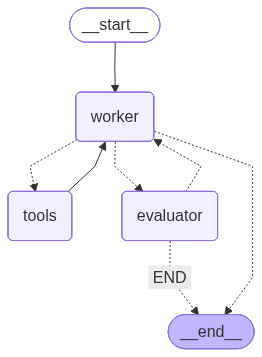

In [13]:
display(Image(graph.get_graph().draw_mermaid_png()))

### Em seguida vem o callback do Gradio para iniciar um super-step


In [14]:
def make_thread_id() -> str:
    return str(uuid.uuid4())


async def process_message(message, success_criteria, history, thread):

    config = {"configurable": {"thread_id": thread}}

    state = {
        "messages": message,
        "success_criteria": success_criteria,
        "feedback_on_work": None,
        "success_criteria_met": False,
        "user_input_needed": False
    }
    result = await graph.ainvoke(state, config=config)
    user = {"role": "user", "content": message}
    reply = {"role": "assistant", "content": result["messages"][-2].content}
    feedback = {"role": "assistant", "content": result["messages"][-1].content}
    return history + [user, reply, feedback]

async def reset():
    return "", "", None, make_thread_id()



### E agora lançamos a UI do Sidekick


In [15]:

with gr.Blocks(theme=gr.themes.Default(primary_hue="emerald")) as demo:
    gr.Markdown("## Sidekick - colega pessoal")
    thread = gr.State(make_thread_id())
    
    with gr.Row():
        chatbot = gr.Chatbot(label="Sidekick", height=300, type="messages")
    with gr.Group():
        with gr.Row():
            message = gr.Textbox(show_label=False, placeholder="Seu pedido para o seu sidekick")
        with gr.Row():
            success_criteria = gr.Textbox(show_label=False, placeholder="Quais são seus critérios de sucesso?")
    with gr.Row():
        reset_button = gr.Button("Reiniciar", variant="stop")
        go_button = gr.Button("Ir!", variant="primary")
    message.submit(process_message, [message, success_criteria, chatbot, thread], [chatbot])
    success_criteria.submit(process_message, [message, success_criteria, chatbot, thread], [chatbot])
    go_button.click(process_message, [message, success_criteria, chatbot, thread], [chatbot])
    reset_button.click(reset, [], [message, success_criteria, chatbot, thread])

    
demo.launch()


* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


Traceback (most recent call last):
  File "/home/santclear/udemy-agentic-course/.venv/lib/python3.12/site-packages/gradio/queueing.py", line 625, in process_events
    response = await route_utils.call_process_api(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/santclear/udemy-agentic-course/.venv/lib/python3.12/site-packages/gradio/route_utils.py", line 322, in call_process_api
    output = await app.get_blocks().process_api(
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/santclear/udemy-agentic-course/.venv/lib/python3.12/site-packages/gradio/blocks.py", line 2220, in process_api
    result = await self.call_function(
             ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/santclear/udemy-agentic-course/.venv/lib/python3.12/site-packages/gradio/blocks.py", line 1729, in call_function
    prediction = await fn(*processed_input)
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/santclear/udemy-agentic-course/.venv/lib/python3.12/site-packages/grad

<table style="margin: 0; text-align: left; width:100%">
    <tr>
        <td style="width: 150px; height: 150px; vertical-align: middle;">
            <img src="../assets/thanks.png" width="150" height="150" style="display: block;" />
        </td>
        <td>
            <h2 style="color:#00cc00;">Parabéns por criar a primeira versão do Sidekick!</h2>
            <span style="color:#00cc00;">Este é um momento bem épico no curso. Você criou o início de algo muito poderoso. E aprimorou suas habilidades em um framework de agentes impressionante no LangGraph. Talvez, como eu, você esteja deixando de ser cético em relação ao LangGraph para virar fã do LangGraph..<br/><br/>Meu editor me mataria se eu não mencionasse de novo: se você puder avaliar o curso na Udemy, eu ficarei muito grato; é a principal forma de a Udemy decidir se mostra o curso para outras pessoas e faz uma enorme diferença.<br/><br/>E mais um lembrete de que eu adoro <a href="https://www.linkedin.com/in/eddonner/">me conectar no LinkedIn</a> se você ainda não fez isso! Se quiser postar sobre o seu progresso no curso, por favor me marque e eu vou aparecer para aumentar sua exposição.
            </span>
        </td>
    </tr>